# Readmission Risk — Explainability (SHAP)

Adds "why" to the readmission model's predictions. SHAP (SHapley Additive exPlanations)
attributes each prediction to the specific features that pushed it up or down — turning
a bare risk score into something a clinician could actually act on.

**Prerequisite:** run `notebooks/03_diabetes_training.ipynb` first so the trained model
exists in `models/`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

model = joblib.load("models/diabetes_readmission_model.pkl")
encoder = joblib.load("models/diabetes_encoder.pkl")
feature_names = joblib.load("models/diabetes_feature_names.pkl")

df = pd.read_csv("data/processed_diabetes.csv")
y = df["readmit_30d"]
X = df.drop(columns=["readmit_30d"])
cat_cols = X.select_dtypes(include="object").columns.tolist()
X[cat_cols] = encoder.transform(X[cat_cols])
X = X[feature_names]

print(f"Loaded model and data: {X.shape}")

/tmp/ipykernel_514/2509886726.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


Loaded model and data: (71515, 45)


## 1. Build the explainer

`TreeExplainer` is fast and exact for tree-based models like XGBoost (unlike the more
general `KernelExplainer`, which approximates and is much slower). We compute SHAP
values on a sample rather than the full 71K rows — a few hundred is enough to see clear
population-level patterns, and it keeps this notebook fast to re-run.

In [2]:
explainer = shap.TreeExplainer(model)

sample = X.sample(500, random_state=42)
shap_values = explainer.shap_values(sample)

print(f"SHAP values shape: {shap_values.shape}")  # (n_samples, n_features)

SHAP values shape: (500, 45)


## 2. Population-level view: which features matter most overall?

The summary plot shows every sampled patient as a dot for each feature — color shows
whether that patient's value was high (red) or low (blue), and position shows whether it
pushed their risk score up or down. This is the "big picture" view of the model.

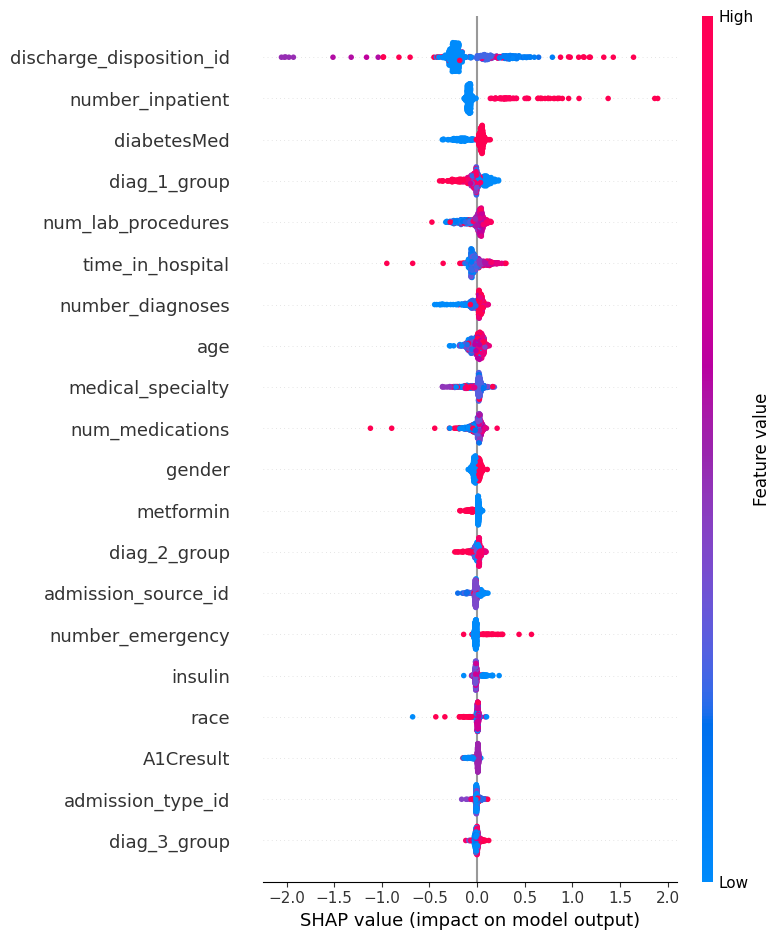

In [3]:
shap.summary_plot(shap_values, sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("models/diabetes_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Individual patient explanation

This is the piece that actually powers the dashboard's "why this score" panel — for any
single patient, a waterfall plot shows exactly which features pushed their specific risk
score up or down, and by how much.

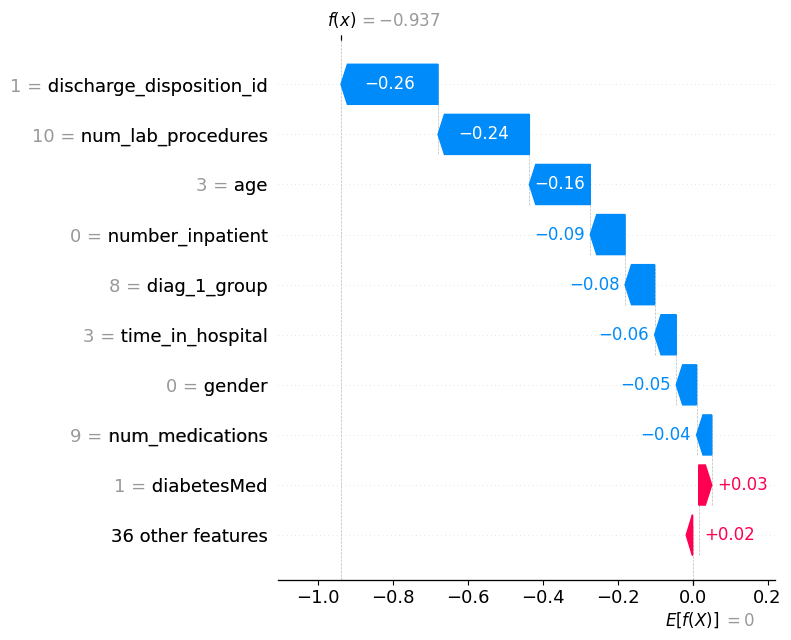

Predicted 30-day readmission risk for this patient: 28.1%


In [4]:
patient_idx = 0  # change this to inspect a different patient in the sample

explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=sample.iloc[patient_idx],
    feature_names=feature_names,
)

shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig("models/diabetes_shap_waterfall_example.png", dpi=150, bbox_inches="tight")
plt.show()

predicted_prob = model.predict_proba(sample.iloc[[patient_idx]])[0, 1]
print(f"Predicted 30-day readmission risk for this patient: {predicted_prob:.1%}")

## 4. Save the explainer for the dashboard

We save the fitted `TreeExplainer` so the Streamlit dashboard can compute a live
explanation for any patient a user selects, without recomputing SHAP from scratch.

In [5]:
joblib.dump(explainer, "models/diabetes_shap_explainer.pkl")
print("Saved SHAP explainer to models/diabetes_shap_explainer.pkl")

Saved SHAP explainer to models/diabetes_shap_explainer.pkl
